In [1]:
import numpy as np

np.random.seed(42)

X = np.array([
    [1,0],
    [0,1],
    [1,1]
])

y = np.array([[1]])

input_size = 2
hidden_size = 3
output_size = 1

# Forget Gate
Wf = np.random.randn(input_size+hidden_size, hidden_size)*0.1
bf = np.zeros((1,hidden_size))

# Input Gate
Wi = np.random.randn(input_size+hidden_size, hidden_size)*0.1
bi = np.zeros((1,hidden_size))

# Candidate Cell
Wc = np.random.randn(input_size+hidden_size, hidden_size)*0.1
bc = np.zeros((1,hidden_size))

# Output Gate
Wo = np.random.randn(input_size+hidden_size, hidden_size)*0.1
bo = np.zeros((1,hidden_size))

# Output Layer
Wy = np.random.randn(hidden_size,output_size)*0.1
by = np.zeros((1,output_size))

# Initial Hidden State
h0 = np.zeros((1,hidden_size))

# Initial Cell State
C0 = np.zeros((1,hidden_size))

lr = 0.01
epochs = 1000

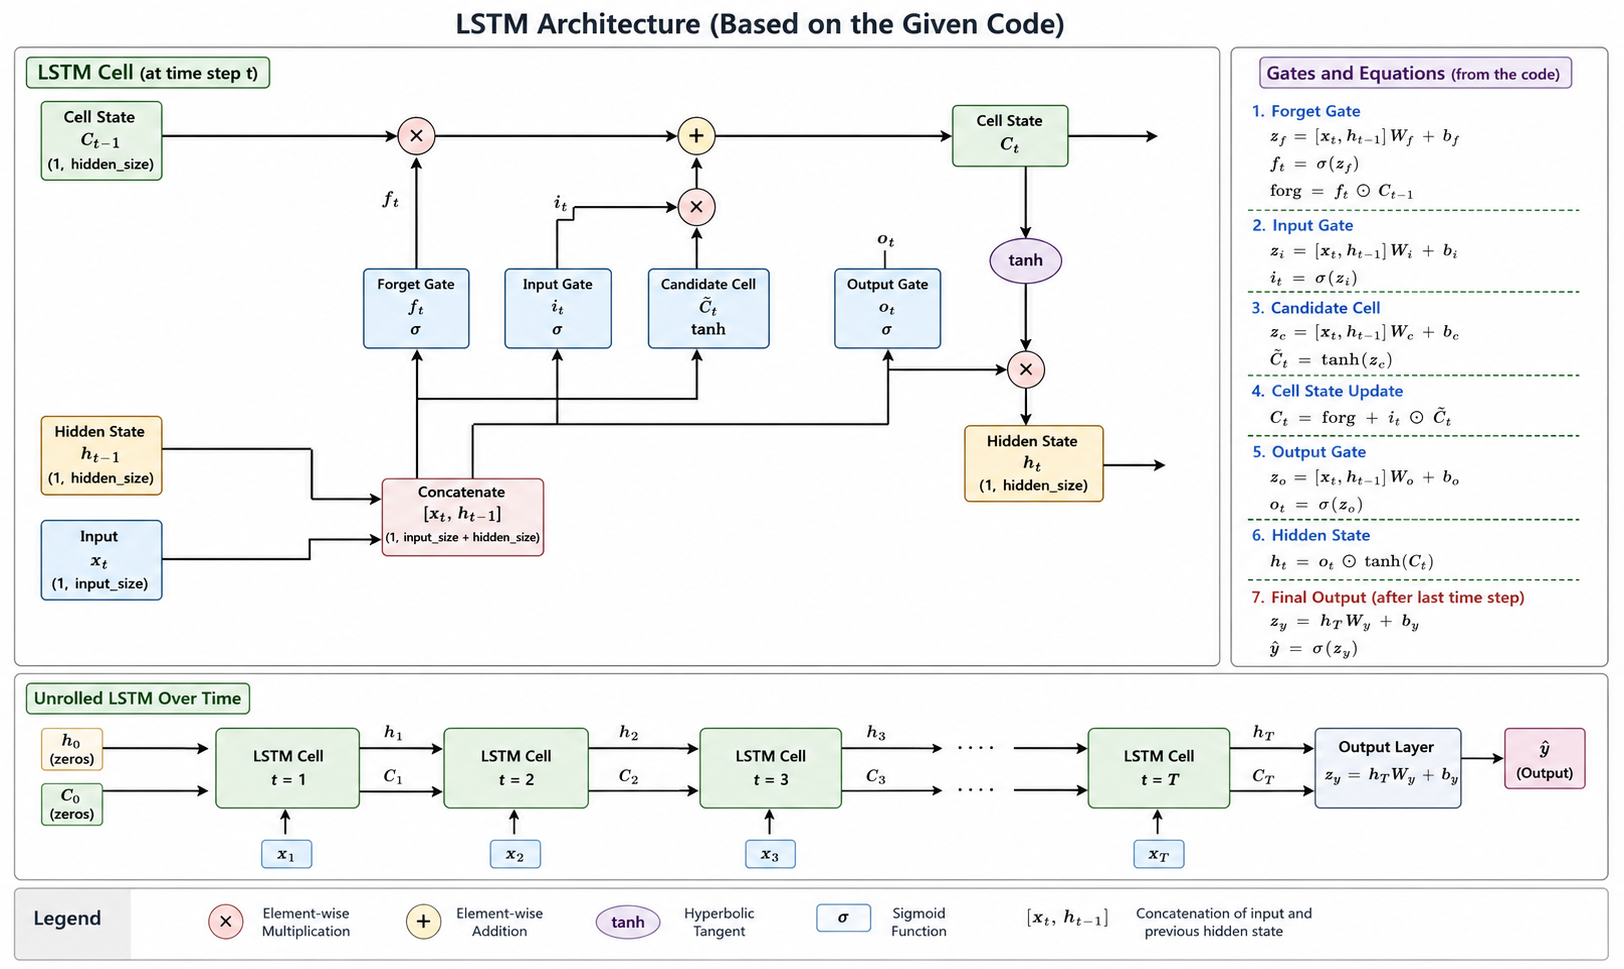

In [ ]:
for epoch in range(epochs):

    h = h0
    C = C0

    for t in range(len(X)):

        x = X[t].reshape(1,-1)

        combined = np.concatenate((x,h),axis=1)

        # Forget Gate
        zf = np.dot(combined,Wf) + bf
        f = 1/(1+np.exp(-zf))

        # Input Gate
        zi = np.dot(combined,Wi) + bi
        it = 1/(1+np.exp(-zi))

        # Candidate Cell
        zc = np.dot(combined,Wc) + bc
        c_bar = np.tanh(zc)

        # Cell State
        C = f*C + it*c_bar

        # Output Gate
        zo = np.dot(combined,Wo) + bo
        ot = 1/(1+np.exp(-zo))

        # Hidden State
        h = ot*np.tanh(C)

    # Final Output
    zy = np.dot(h,Wy) + by

    y_hat = 1/(1+np.exp(-zy))